# **1. PREPARACIÓN DEL ENTORNO**

## **1.1 Instalación de librerías**

In [ ]:
!pip install transformers[sentencepiece]  #Instalar únicamente un módulo, no el paquete completo
!pip install pandas

## **1.2 Importar librerías y módulos necesarios**

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

from transformers import pipeline

from pprint import pprint



# **2. ANÁLISIS NLP**

## **2.1 Corpus**

In [ ]:
#url = 'https://raw.githubusercontent.com/navnebror/ml_datasets/refs/heads/main/tripadvisor_hotel_reviews.csv'

#df_hotels = pd.read_csv(url)

comments = [
    "Excellent course, I learned a lot",
    "The class was average",
    "What a waste of time",
    "I loved it 😍",
    "Good content, but too fast-paced",
    "Terrible experience 😡",
    "Sure... excellent service, they kept me waiting...",
    "Does anyone know where to download the materials?",
    "They should provide more examples",
    "Thanks for the help 🙏",
    "2 + 2 = 4",
    "NVIDIA is a big company"
]

df = pd.DataFrame(comments)
print(df)

## **2.3 Análisis de sentimientos**

### **2.3.1 Creación de analizadores (pipelines)**

In [ ]:
sentiment_classifier = pipeline("sentiment-analysis")

### **2.3.2 Ejecución del pipeline**

In [ ]:
'''
El pipeline sentiment-analyzer retorna una LISTA por CADA TEXTO con:

    label: POSITIVE o NEGATIVE
    score: valor entre 0 y 1 que indica que tan confiable es el label
'''

result = sentiment_classifier(comments)
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

#Llevar todo a dataframe para facilitar análisis y lectura
df_sentiments = df.copy()
df_sentiments[['label', 'score']] = pd.DataFrame(result)
print("DATAFRAME CON RESULTADOS")
df_sentiments.head(15)

## **2.4 Análisis de emociones**

### **2.4.1 Creación de analizadores (pipelines)**

In [ ]:
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

### **2.4.2 Ejecución del pipeline**

In [ ]:
'''
El pipeline text-classification retorna una LISTA por CADA TEXTO con:

    label: neutral, joy, disfust, surprise, anger, sadness, fear
    score: valor entre 0 y 1 que indica el peso del label
'''

result = emotion_classifier(comments)
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

#Llevar todo a dataframe para facilitar análisis y lectura
df_emotions = df.copy()

df_emotions = pd.DataFrame([
    {d["label"]: d["score"] for d in row}
    for row in result
])

# Agregar columna de comentarios al inicio
df_emotions = pd.concat([pd.DataFrame({'comment': comments}), df_emotions], axis=1)

print("DATAFRAME CON RESULTADOS")
df_emotions.head(15)

## **2.5 Análisis de subjetividad**

### **2.5.1 Creación de analizadores (pipelines)**

In [ ]:
subjectivity_classifier = pipeline(
    "text-classification",
    model="GroNLP/mdebertav3-subjectivity-english"
)

### **2.5.2 Ejecución del pipeline**

In [ ]:
'''
El pipeline text-classification retorna una LISTA por CADA TEXTO con:

    label: LABEL_0 = OBJETIVO, LABEL_1 = SUBJETIVO
    score: valor entre 0 y 1 que indica el peso del label
'''

result = subjectivity_classifier(comments)
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

#Llevar todo a dataframe para facilitar análisis y lectura
df_subjectivity = df.copy()
df_subjectivity[['label', 'score']] = pd.DataFrame(result)

df_subjectivity["label"] = df_subjectivity["label"].map({
    "LABEL_0": "OBJECTIVE",
    "LABEL_1": "SUBJECTIVE"
})

print("DATAFRAME CON RESULTADOS")
df_subjectivity.head(15)

## **2.6 Análisis de intención**

### **2.6.1 Creación de analizadores (pipelines)**

In [ ]:
intent_classifier = pipeline(
    "text-classification",
    model="qanastek/XLMRoberta-Alexa-Intents-Classification",
    top_k=None
)

### **2.6.2 Ejecución del pipeline**

In [ ]:
'''
El pipeline text-classification retorna una LISTA por CADA TEXTO con:

    label: descripción de la intención (según el modelo seleccionado)
    score: valor entre 0 y 1 que indica el peso del label
'''

result = intent_classifier(comments)
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

#Llevar todo a dataframe para facilitar análisis y lectura
df_intent = df.copy()

df_intent = pd.DataFrame([
    {d["label"]: d["score"] for d in row}
    for row in result
]).round(4)

# Agregar columna de comentarios al inicio
df_intent = pd.concat([pd.DataFrame({'comment': comments}), df_intent], axis=1)

print("DATAFRAME CON RESULTADOS")
df_intent.head(15)

## **2.7 Análisis de sarcasmo**

### **2.7.1 Creación de analizadores (pipelines)**

In [ ]:
sarcasm_classifier = pipeline(
    "text-classification",
    model="jkhan447/sarcasm-detection-RoBerta-base-POS"
)

### **2.7.2 Ejecución del pipeline**

In [ ]:
'''
El pipeline text-classification retorna una LISTA por CADA TEXTO con:

    label: LABEL_0 (no sarcástico), LABEL_1 (sarcástico)
    score: valor entre 0 y 1 que indica el peso del label
'''

result = sarcasm_classifier(comments)
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

#Llevar todo a dataframe para facilitar análisis y lectura
df_sarcasm = df.copy()
df_sarcasm[['label', 'score']] = pd.DataFrame(result)

df_sarcasm["label"] = df_sarcasm["label"].map({
    "LABEL_0": "NO SARCASM",
    "LABEL_1": "SARCASM"
})

print("DATAFRAME CON RESULTADOS")
df_sarcasm.head(15)

# **3. EJERCICIOS**

## **3.1 Obtener datos de prueba**

En la siguiente url hay comentarios de hoteles de TripAdvisor. Crear un dataframe llamado "df" con el contenido de este archivo

https://raw.githubusercontent.com/navnebror/ml_datasets/refs/heads/main/tripadvisor_hotel_reviews.csv

In [ ]:
#Código aquí para crear el DataFrame
url = 'https://raw.githubusercontent.com/navnebror/ml_datasets/refs/heads/main/tripadvisor_hotel_reviews.csv'
df = pd.read_csv(url)
df2=df.copy().head(100)
df2.head(30)

## **3.2 estadísticas básicas**

Una vez creado el dataframe, aplicar los análisis vistos en la sección 2.

Siéntase libre de usar el método que prefiera. Puede crear un solo dataframe con TODOS los análisis, o crear uno por cada tipo de análisis (tal como se hizo en la sección 2).



In [ ]:
#Código aquí para crear los clasificadores o analizadores de cada tipo de sentimiento
#
sentiment_classifier = pipeline("sentiment-analysis")
#
#

In [ ]:
result = sentiment_classifier(df2['Review'].tolist(), truncation=True)
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

#Llevar todo a dataframe para facilitar análisis y lectura
df_sentiments = df.copy()
df_sentiments[['label', 'score']] = pd.DataFrame(result)
print("DATAFRAME CON RESULTADOS")
df_sentiments.head(15)

## Clasificación de emociones

In [ ]:
##Clasificación de emociones
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

In [ ]:
##Ejecución del pipeline
result = emotion_classifier(df2['Review'].tolist())
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

##Llevar todo a dataframe para facilitar el análisis y lectura
df_emotions = df.copy()

df_emotions = pd.DataFrame([
    {d["label"]: d["score"] for d in row}
    for row in result
])

## Agregar columna de comentarios al inicio
df_emotions = pd.concat([pd.DataFrame({'comentarios': df2['Review']}), df_emotions], axis=1)

print("DATAFRAME CON RESULTADOS")
df_emotions.head(15)

## Análisis de subjetividad

In [ ]:
##Creación de analizadores
subjectivity_classifier = pipeline(
    "text-classification",
    model="GroNLP/mdebertav3-subjectivity-english"
)

In [ ]:
##Ejecución del Pipeline
result = subjectivity_classifier(df2['Review'].tolist())
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

##Llevar todo a dataframe para facilitar análisis y lectura
df_subjectivity = df.copy()
df_subjectivity[['label', 'score']] = pd.DataFrame(result)

df_subjectivity["label"] = df_subjectivity["label"].map({
    "LABEL_0": "OBJECTIVE",
    "LABEL_1": "SUBJECTIVE"
})

print("DATAFRAME CON RESULTADOS")
df_subjectivity.head(15)

## Análisis de intención

In [ ]:
##Creación de Analizadores
intent_classifier = pipeline(
    "text-classification",
    model="qanastek/XLMRoberta-Alexa-Intents-Classification",
    top_k=None
)

In [ ]:
## Ejecución del Pipiline
result = intent_classifier(df2['Review'].tolist())
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

#Llevar todo a Dataframe para facilitar el análisis y lectura
df_intent = df.copy()

df_intent = pd.DataFrame([
    {d["label"]: d["score"] for d in row}
    for row in result
]).round(4)

# Agregar columna de comentarios al inicio
df_intent = pd.concat([pd.DataFrame({'Comentario': df2['Review']}), df_intent], axis=1)

print("DATAFRAME CON RESULTADOS")
df_intent.head(15)

## Análisis de sarcasmo

In [ ]:
##Creación de Analizadores
sarcasm_classifier = pipeline(
    "text-classification",
    model="jkhan447/sarcasm-detection-RoBerta-base-POS"
)


In [ ]:
##Ejecución de Pipeline
result = sarcasm_classifier(df2['Review'].tolist())
print("RESULTADO DEL PIPELINE")
pprint(result)
print("--------------------")

# Llevar todo a dataframe para facilitar análisis y lectura
df_sarcasm = df.copy()
df_sarcasm[['label', 'score']] = pd.DataFrame(result)

df_sarcasm["label"] = df_sarcasm["label"].map({
    "LABEL_0": "NO SARCASM",
    "LABEL_1": "SARCASM"
})

print("DATAFRAME CON RESULTADOS")
df_sarcasm.head(15)

### **3.2.1 Distribución porcentual de sentimientos**

Escribir código de Pandas para mostrar la distribución de sentimientos de forma que de una salida similar a esta:



```
 sentimiento
POSITIVE    30.0
NEGATIVE    50.0
NEUTRAL     20.0
```



In [ ]:
#Código aquí

df_sentiments['label'].value_counts(normalize=True) * 100

### **3.2.2 Distribución cuantitativa de emociones**

Escribir código de Pandas para mostrar la cantidad de emociones agrupadas por emoción de una forma similar a la siguiente



```
 emocion
neutral     18
joy          8
disgust      3
sadness      3
fear         2
anger        1
surprise     1
```

In [ ]:
#Código aquí

# Select only the emotion score columns, find the emotion with the maximum score for each row,
# then count the occurrences of each dominant emotion and sort them.
df_emotions[['joy', 'fear', 'neutral', 'surprise', 'sadness', 'anger', 'disgust']].idxmax(axis=1).value_counts().sort_values(ascending=False)

### **3.2.2 Modificado: Que los nombres de las emociones sean en español**

PISTA: Usar diccionarios nativos y la función "map"

In [ ]:
#Código aquí

emociones_es = {
    'joy': 'alegría',
    'fear': 'miedo',
    'surprise': 'sorpresa',
    'anger': 'ira',
    'sadness': 'tristeza',
    'neutral': 'neutral',
    'disgust': 'asco'
}

# Calcular el conteo de emociones en 'resultado'
resultado = df_emotions[['joy', 'fear', 'neutral', 'surprise', 'sadness', 'anger', 'disgust']].idxmax(axis=1).value_counts().sort_values(ascending=False)

resultado.index = resultado.index.map(emociones_es)

print(resultado)

### **3.2.3 Distribución porcentual de subjetividad**

Escribir código de Pandas para mostrar la distribución porcentual de objetividad y subjetividad de una forma similar a la siguiente:



```
 subjetividad
OBJETIVO     75.0
SUBJETIVO    25.0
```

In [ ]:
#Código aquí
df_subjectivity['label'].value_counts(normalize=True) * 100

### **3.2.4 Distribución cuantitativa de intención**

Escribir código de Pandas para mostrar la cantidad de intenciones agrupadas por intención de una forma similar a la siguiente



```
 emocion
general_quirky     18
music_likeness      8
...
...
...
```

In [ ]:
#Código aquí
df_intent.drop(columns=['Comentario']).idxmax(axis=1).value_counts()

### **3.2.5 Distribución porcentual de sacrasmo**

Escribir código de Pandas para mostrar la distribución de ironía de forma que de una salida similar a esta:



```
 sarcasmo
NO    83.333333
SI    16.666667
```

In [ ]:
#Código aquí

df_sarcasm['label'].value_counts(normalize=True) * 100

## **3.3 Traducción con Hugging Face**

Mostrar un DataFrame con los comentarios originales (corpus de la sección 2.1) en una columna, y los comentarios en francés en otra.

NOTA: ***De forma intensional no se proporciona ejemplo para esta funcionalidad***, pero si explora la documentación de HuggingFace buscando el modelo "Helsinki-NLP", encontrará como resolverlo rápidamente.

In [ ]:
#Código aquí

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


model_name = "Helsinki-NLP/opus-mt-en-fr"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

translated_texts = []
for text in comments:
    inputs = tokenizer(text, return_tensors="pt")
    outputs = model.generate(**inputs)
    translated_texts.append(tokenizer.decode(outputs[0], skip_special_tokens=True))

df_fr = pd.DataFrame({
    "comment": comments,
    "french_comment": translated_texts
})

print(df_fr)

## **3.4 Traducción con Google**

In [ ]:
#Instalación de la librería
!pip install deep-translator

### **3.4.1 Ejemplo**

El siguiente código muestra como traducir un texto, proporcionando el origen y el destino.


```
from deep_translator import GoogleTranslator

idioma_origen = 'auto' #Google detecta el idioma
idioma_destino = 'es'
texto = "Hello, how are you?"

translated = GoogleTranslator(source=idioma_origen, target=idioma_destino).translate(texto)
print(translated)
```



### **3.4.2 traducción de comentarios del corpus creado en la sección 2.1**

Utilizando el ejemplo de la sección anterior, crear un dataframe con los comentarios en su idioma original en una columna, y los comentarios en francés en otra columna

In [ ]:
#Código aquí

from deep_translator import GoogleTranslator
import pandas as pd

idioma_origen = 'auto' #Google detecta el idioma
idioma_destino = 'fr'
comments = [
    "Excellent course, I learned a lot",
    "The class was average",
    "What a waste of time",
    "I loved it 😍",
    "Good content, but too fast-paced",
    "Terrible experience 😡",
    "Sure... excellent service, they kept me waiting...",
    "Does anyone know where to download the materials?",
    "They should provide more examples",
    "Thanks for the help 🙏",
    "2 + 2 = 4",
    "NVIDIA is a big company"
]

traduccion_comentarios = []
for comment in comments:
    traduccion_comentarios.append(GoogleTranslator(source=idioma_origen, target=idioma_destino).translate(comment))

df_google_fr = pd.DataFrame({
    "comment": comments,
    "french_comment": traduccion_comentarios
})
print(df_google_fr)

### **3.4.3 : Versión modificado 3.3.2: Que los nombres de las emociones sean en español**

PISTA: Usar diccionarios nativos y la función "map"

In [ ]:
#Código aquí

idioma_origen = 'auto' #Google detecta el idioma
idioma_destino = 'es'
emociones = ['joy', 'fear', 'neutral', 'surprise', 'sadness', 'anger', 'disgust']

traduccion_emociones = []
for emociones in emociones:
    traduccion_emociones.append(GoogleTranslator(source=idioma_origen, target=idioma_destino).translate(emociones))

df_google_emociones_espanol = pd.DataFrame({
    "emociones": emocion,
    "espanol_emociones": traduccion_emociones
})
print(df_google_emociones_espanol)

# **4 Explorar más modelos en HuggingFace**

Acceder a la url https://huggingface.co/models?sort=trending

Para cada uno de los análisis (sentimientos, emociones, objetividad, etc), explorar modelos diferentes usando el cuadro de búsqueda como se muestra en la imagen. Ejecutar de nuevo los ejercicios anteriores con los modelos seleccionados para ver que modelos dan resultados diferentes o más confiables

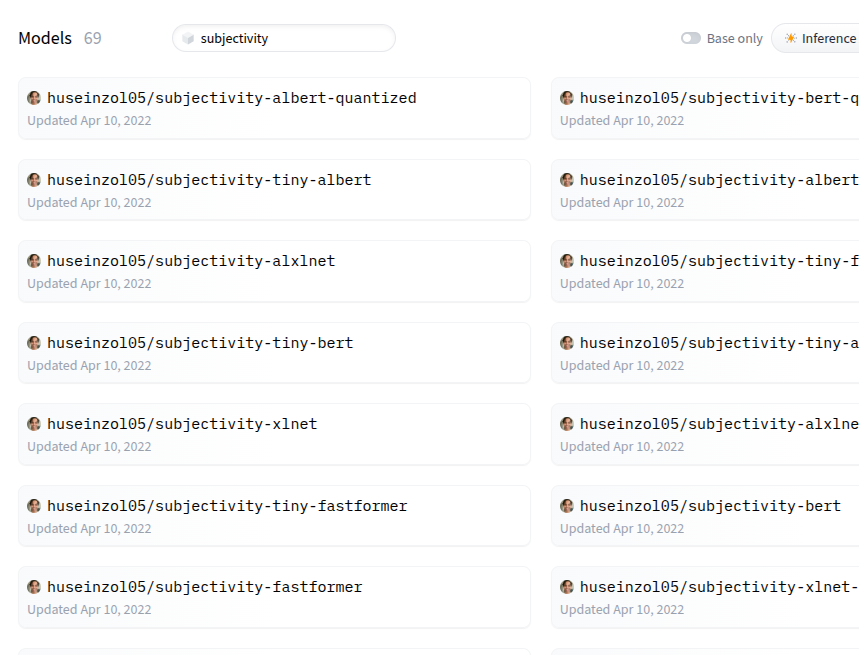